# Customer Churn Analysis – Clustering (Revised)
## Data Analyst – Clustering | Advanced Telecommunications Solutions (ATS)

### Objective
Segment ATS customers using **tenure** and **MonthlyCharges** with K-Means. Select K using the Elbow Method and Silhouette Score, visualise the segments, then compare churn rates across them.

**Important:** `Churn` is excluded from model inputs and used only after clustering to profile each segment. This avoids using the outcome to create the groups.

### Workflow
1. Load and check the team-preprocessed dataset.
2. Select and standardise `tenure` and `MonthlyCharges`.
3. Compare K values using Elbow and Silhouette diagnostics.
4. Fit K-Means and assign cluster labels.
5. Visualise and profile segments, including churn rate.
6. Summarise findings and export the dataset for the team.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load the preprocessed dataset

In [2]:
url = "https://raw.githubusercontent.com/NithinVarghese97/Customer_Churn_Analysis/main/Data_Preparation/Preprocessed_Dataset/Dataset_ATS_v2_preprocessed.csv"
df = pd.read_csv(url)
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (6741, 12)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year
0,0,0,0,1,0,0,0,25,1,1,0,0
1,1,0,0,41,1,0,0,25,0,0,1,0
2,0,0,1,52,1,0,0,19,0,1,0,0
3,0,0,0,1,1,0,0,76,1,0,1,0
4,1,0,0,67,1,0,1,51,0,1,0,0


## 2. Data quality checks

In [3]:
print("Missing values:", int(df.isnull().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))
print("Columns:", df.columns.tolist())
print("\nClustering feature data types:")
print(df[['tenure', 'MonthlyCharges']].dtypes)

Missing values: 0
Duplicate rows: 1
Columns: ['gender', 'SeniorCitizen', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'MonthlyCharges', 'Churn', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']

Clustering feature data types:
tenure            int64
MonthlyCharges    int64
dtype: object


The source dataset contains a duplicate-row check. This notebook does not silently remove rows, to keep consistency with the team's preprocessed data.

## 3. Select clustering features

In [4]:
clustering_features = ['tenure', 'MonthlyCharges']
X = df[clustering_features].copy()

if X.isnull().any().any():
    raise ValueError("Missing values found in clustering features; resolve before fitting K-Means.")

print("Features:", clustering_features)
print("Clustering matrix:", X.shape)
X.describe()


Features: ['tenure', 'MonthlyCharges']
Clustering matrix: (6741, 2)


,tenure,MonthlyCharges
count,6741.00,6741.00
mean,32.95,65.84
std,24.33,29.68
min,0.00,18.00
25%,10.00,41.00
50%,30.00,71.00
75%,56.00,90.00
max,72.00,119.00


### Why these two variables?
`tenure` represents how long a customer has stayed with the company, while `MonthlyCharges` represents their monthly bill. They match this role's agreed segmentation focus. We do not include `Churn` as a clustering input.

## 4. Standardise the clustering features

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaled data shape:", X_scaled.shape)


Scaled data shape: (6741, 2)


Standardisation places both variables on a comparable scale before K-Means calculates distances. The scaler is applied to these two clustering features only; the original dataframe values remain unchanged for interpretation.

## 5. Choose the number of clusters

In [6]:
k_range = range(2, 11)
inertia = []
silhouette_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = model.fit_predict(X_scaled)
    inertia.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

scores = pd.DataFrame({
    'K': list(k_range),
    'Inertia': inertia,
    'Silhouette_Score': silhouette_scores
})
scores


,K,Inertia,Silhouette_Score
0,2,7593.82,0.41
1,3,4434.86,0.45
2,4,2796.71,0.47
3,5,2295.41,0.43
4,6,1895.35,0.43
5,7,1527.44,0.43
6,8,1322.56,0.43
7,9,1139.08,0.43
8,10,1000.29,0.42


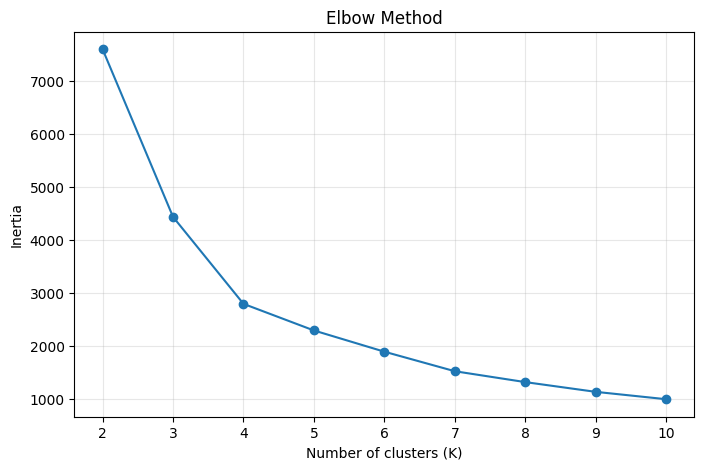

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()


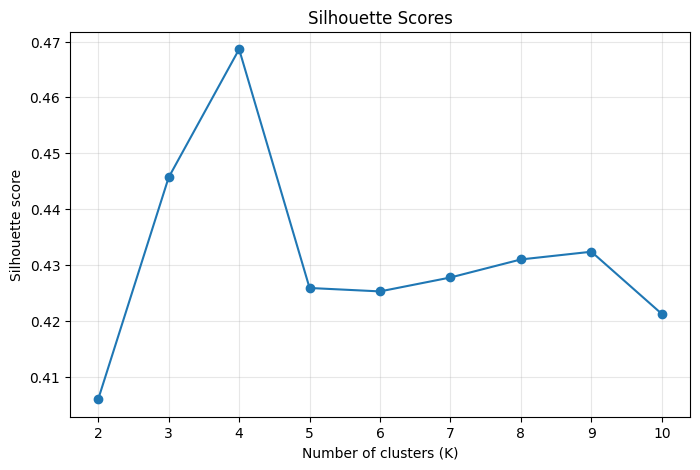

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='o')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette score')
plt.title('Silhouette Scores')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.show()


### Select K

Review both plots before finalising K. The Elbow Method helps identify where the reduction in inertia begins to level off; the Silhouette Score measures cluster separation and cohesion (higher is better, with a range from -1 to 1).

For this run, **K=4 is selected** because it has the highest observed silhouette score among the tested values (**0.47**) and the inertia reduction begins to become less pronounced after four clusters. This provides a reasonable balance between separation and model simplicity.

The final model below therefore uses `optimal_k = 4`.

In [9]:
# Final K selected from the Elbow and Silhouette diagnostics above.
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

df['Cluster'] = kmeans.fit_predict(X_scaled)

print(f"Final K-Means model trained with K={optimal_k}")
print("\nCluster sizes:")
print(df['Cluster'].value_counts().sort_index())

Final K-Means model trained with K=4

Cluster sizes:
Cluster
0    1118
1    1914
2    1584
3    2125
Name: count, dtype: int64


## 6. Visualise the customer segments

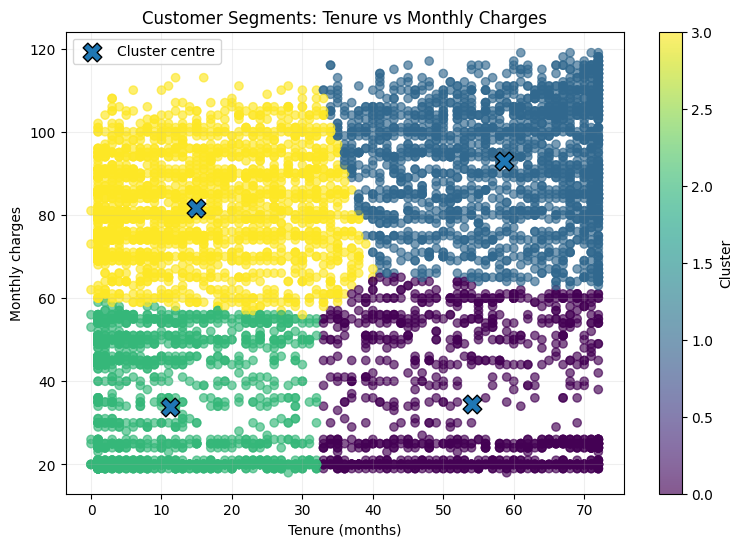

In [10]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    df['tenure'],
    df['MonthlyCharges'],
    c=df['Cluster'],
    alpha=0.65
)

# Convert K-Means centres back to the original feature scale.
centres = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centres[:, 0],
    centres[:, 1],
    marker='X',
    s=180,
    edgecolor='black',
    label='Cluster centre'
)

plt.xlabel('Tenure (months)')
plt.ylabel('Monthly charges')
plt.title('Customer Segments: Tenure vs Monthly Charges')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Each colour represents a cluster. Cluster numbers are labels only; they do not imply rank or order.

## 7. Profile clusters and compare churn

In [11]:
cluster_profile = df.groupby('Cluster').agg(
    Customer_Count=('Cluster', 'size'),
    Average_Tenure=('tenure', 'mean'),
    Average_Monthly_Charges=('MonthlyCharges', 'mean'),
    Churn_Rate=('Churn', 'mean')
)
cluster_profile['Customer_Percent'] = (
    cluster_profile['Customer_Count'] / len(df) * 100
)
cluster_profile['Churn_Rate'] *= 100
cluster_profile = cluster_profile.round(2)
cluster_profile


,Customer_Count,Average_Tenure,Average_Monthly_Charges,Churn_Rate,Customer_Percent
Cluster,,,,,
0,1118,54.02,34.54,4.92,16.59
1,1914,58.59,93.03,15.83,28.39
2,1584,11.23,33.84,25.00,23.50
3,2125,14.95,81.68,48.80,31.52


In [12]:
overall_churn = df['Churn'].mean() * 100
highest_churn_cluster = cluster_profile['Churn_Rate'].idxmax()
lowest_churn_cluster = cluster_profile['Churn_Rate'].idxmin()

print(f"Overall churn rate: {overall_churn:.2f}%")
print(f"Highest observed cluster churn: Cluster {highest_churn_cluster} "
      f"({cluster_profile.loc[highest_churn_cluster, 'Churn_Rate']:.2f}%)")
print(f"Lowest observed cluster churn: Cluster {lowest_churn_cluster} "
      f"({cluster_profile.loc[lowest_churn_cluster, 'Churn_Rate']:.2f}%)")


Overall churn rate: 26.57%
Highest observed cluster churn: Cluster 3 (48.80%)
Lowest observed cluster churn: Cluster 0 (4.92%)


In [13]:
# Create a concise, data-driven interpretation for each cluster.
for cluster, row in cluster_profile.sort_index().iterrows():
    tenure_desc = "shorter-tenure" if row['Average_Tenure'] < df['tenure'].median() else "longer-tenure"
    charge_desc = "lower-charge" if row['Average_Monthly_Charges'] < df['MonthlyCharges'].median() else "higher-charge"
    churn_vs_overall = "above" if row['Churn_Rate'] > overall_churn else "below"
    print(
        f"Cluster {cluster}: {tenure_desc} / {charge_desc} customers; "
        f"{int(row['Customer_Count']):,} customers ({row['Customer_Percent']:.2f}%); "
        f"average tenure {row['Average_Tenure']:.2f} months; "
        f"average monthly charges ${row['Average_Monthly_Charges']:.2f}; "
        f"observed churn {row['Churn_Rate']:.2f}%, {churn_vs_overall} the overall rate of {overall_churn:.2f}%."
    )

print("\nBusiness interpretation:")
print("The cluster with the highest observed churn rate may warrant closer retention investigation. "
      "These are descriptive associations only and do not show that tenure or monthly charges cause churn.")

Cluster 0: longer-tenure / lower-charge customers; 1,118 customers (16.59%); average tenure 54.02 months; average monthly charges $34.54; observed churn 4.92%, below the overall rate of 26.57%.
Cluster 1: longer-tenure / higher-charge customers; 1,914 customers (28.39%); average tenure 58.59 months; average monthly charges $93.03; observed churn 15.83%, below the overall rate of 26.57%.
Cluster 2: shorter-tenure / lower-charge customers; 1,584 customers (23.50%); average tenure 11.23 months; average monthly charges $33.84; observed churn 25.00%, below the overall rate of 26.57%.
Cluster 3: shorter-tenure / higher-charge customers; 2,125 customers (31.52%); average tenure 14.95 months; average monthly charges $81.68; observed churn 48.80%, above the overall rate of 26.57%.

Business interpretation:
The cluster with the highest observed churn rate may warrant closer retention investigation. These are descriptive associations only and do not show that tenure or monthly charges cause churn

## 8. Limitations

- The segments use only `tenure` and `MonthlyCharges`; other customer characteristics are not included in this clustering.
- K-Means results depend on feature scaling, the selected K, and random initialisation.
- Cluster numbers are arbitrary identifiers and do not imply rank or priority.
- Comparing churn by cluster is descriptive and does not establish causation.
- The selected K is based on the diagnostics in this run; if the underlying dataset changes, the analysis should be rerun.
- A cluster label should be treated as a categorical feature in downstream modelling, not as a numeric ranking.

## 9. Export the clustered dataset

In [14]:
output_path = "Dataset_ATS_v2_with_clusters.csv"
df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print("Export shape:", df.shape)


Saved: Dataset_ATS_v2_with_clusters.csv
Export shape: (6741, 13)
